# Quiz: Stochastic Process Simulations

This notebook simulates and compares three discrete-time stochastic systems:
1. AWGN filtered by a low-pass system $H(\omega)$
2. AR(3) process
3. ARMA(3, 3) process

Each part includes a short analytical model and an empirical time-domain simulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray

plt.style.use("seaborn-v0_8-whitegrid")


def design_fir_lpf(
    sample_rate_hz: float,  # Sampling frequency [Hz]
    cutoff_hz: float,  # Low-pass cutoff frequency [Hz]
    num_taps: int,  # FIR length [samples], must be odd
) -> NDArray[np.float64]:  # FIR impulse response h[n] with unit DC gain
    """Designs a linear-phase FIR LPF approximation to H(w) using windowed-sinc.

    Purpose:
        Build a practical discrete-time LPF for filtering white Gaussian noise.

    Parameters:
        sample_rate_hz: Sampling frequency in Hz.
        cutoff_hz: Desired cutoff frequency in Hz.
        num_taps: Number of FIR coefficients (odd for symmetry).

    Returns:
        Real FIR coefficients h[n], normalized to preserve DC gain.

    Side effects:
        None.
    """
    if sample_rate_hz <= 0.0:
        raise ValueError("sample_rate_hz must be positive.")
    if not (0.0 < cutoff_hz < sample_rate_hz / 2.0):
        raise ValueError("cutoff_hz must be in (0, sample_rate_hz/2).")
    if num_taps < 3 or num_taps % 2 == 0:
        raise ValueError("num_taps must be an odd integer >= 3.")

    # Create a centered index and ideal LPF impulse response.
    n: NDArray[np.float64] = np.arange(num_taps, dtype=np.float64)
    center: float = (num_taps - 1) / 2.0
    normalized_cutoff: float = cutoff_hz / sample_rate_hz
    h_ideal: NDArray[np.float64] = (
        2.0
        * normalized_cutoff
        * np.sinc(2.0 * normalized_cutoff * (n - center))
    )

    # Apply a Hamming window to reduce sidelobes and normalize DC gain.
    h_windowed: NDArray[np.float64] = h_ideal * np.hamming(num_taps)
    h_windowed /= np.sum(h_windowed)
    return h_windowed.astype(np.float64)


def simulate_ar3(
    num_samples: int,  # Number of output samples [samples]
    ar_coeffs: tuple[float, float, float],  # (a1, a2, a3) in AR recursion
    noise_std: float = 1.0,  # Innovation standard deviation
    burn_in_samples: int = 500,  # Discarded warm-up samples [samples]
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated AR(3) sequence
    """Simulates a stationary AR(3) process with Gaussian innovations.

    Purpose:
        Generate x[n] = a1 x[n-1] + a2 x[n-2] + a3 x[n-3] + w[n],
        where w[n] is zero-mean white Gaussian noise.

    Parameters:
        num_samples: Final sequence length after burn-in.
        ar_coeffs: AR recursion coefficients (a1, a2, a3).
        noise_std: Standard deviation of w[n].
        burn_in_samples: Warm-up length discarded to reduce transients.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` AR(3) realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if noise_std <= 0.0:
        raise ValueError("noise_std must be positive.")
    if burn_in_samples < 0:
        raise ValueError("burn_in_samples must be non-negative.")

    a1, a2, a3 = ar_coeffs
    total_samples: int = num_samples + burn_in_samples

    # Draw innovations and run causal recursion from n=3 onward.
    rng = np.random.default_rng(seed=random_seed)
    innovations: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=total_samples,
    ).astype(np.float64)
    x: NDArray[np.float64] = np.zeros(total_samples, dtype=np.float64)

    for n_idx in range(3, total_samples):
        x[n_idx] = (
            a1 * x[n_idx - 1]
            + a2 * x[n_idx - 2]
            + a3 * x[n_idx - 3]
            + innovations[n_idx]
        )

    return x[burn_in_samples:]


def simulate_arma33(
    num_samples: int,  # Number of output samples [samples]
    ar_coeffs: tuple[float, float, float],  # AR coefficients (a1, a2, a3)
    ma_coeffs: tuple[float, float, float],  # MA coefficients (b1, b2, b3)
    noise_std: float = 1.0,  # Innovation standard deviation
    burn_in_samples: int = 500,  # Discarded warm-up samples [samples]
    random_seed: int = 0,  # Seed for reproducibility
) -> NDArray[np.float64]:  # Simulated ARMA(3,3) sequence
    """Simulates an ARMA(3,3) process with Gaussian innovations.

    Purpose:
        Generate x[n] = sum(a_k x[n-k]) + w[n] + sum(b_k w[n-k])
        with k=1..3, combining long-memory AR feedback and short-memory MA shaping.

    Parameters:
        num_samples: Final sequence length after burn-in.
        ar_coeffs: AR recursion coefficients (a1, a2, a3).
        ma_coeffs: MA coefficients (b1, b2, b3).
        noise_std: Standard deviation of w[n].
        burn_in_samples: Warm-up length discarded to reduce transients.
        random_seed: Seed controlling deterministic simulation.

    Returns:
        Length-`num_samples` ARMA(3,3) realization.

    Side effects:
        None.
    """
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if noise_std <= 0.0:
        raise ValueError("noise_std must be positive.")
    if burn_in_samples < 0:
        raise ValueError("burn_in_samples must be non-negative.")

    a1, a2, a3 = ar_coeffs
    b1, b2, b3 = ma_coeffs

    # Keep three extra innovation samples for MA lags at startup.
    total_samples: int = num_samples + burn_in_samples + 3
    rng = np.random.default_rng(seed=random_seed)
    innovations: NDArray[np.float64] = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=total_samples,
    ).astype(np.float64)
    x: NDArray[np.float64] = np.zeros(total_samples, dtype=np.float64)

    for n_idx in range(3, total_samples):
        # AR term models recursive memory from past outputs.
        ar_term: float = (
            a1 * x[n_idx - 1]
            + a2 * x[n_idx - 2]
            + a3 * x[n_idx - 3]
        )
        # MA term shapes current sample using current and delayed innovations.
        ma_term: float = (
            innovations[n_idx]
            + b1 * innovations[n_idx - 1]
            + b2 * innovations[n_idx - 2]
            + b3 * innovations[n_idx - 3]
        )
        x[n_idx] = ar_term + ma_term

    return x[burn_in_samples + 3 :]


## 1) LPF $H(\omega)$ filtering AWGN (analytical)

Let $x[n] \sim \mathcal{N}(0,\sigma_x^2)$ be white Gaussian noise. For an LTI filter with
impulse response $h[n]$ and frequency response $H(e^{j\omega})$:

$$y[n] = (h * x)[n], \qquad S_y(e^{j\omega}) = |H(e^{j\omega})|^2 S_x(e^{j\omega}).$$

Since white noise has flat spectrum $S_x(e^{j\omega}) = \sigma_x^2$, the LPF attenuates
high-frequency power and reduces output variance according to:

$$\sigma_y^2 = \sigma_x^2 \sum_n h^2[n].$$

Below, $H(\omega)$ is implemented numerically as a windowed-sinc FIR LPF.

LPF output variance (theoretical): 0.1528
LPF output variance (empirical):   0.1516


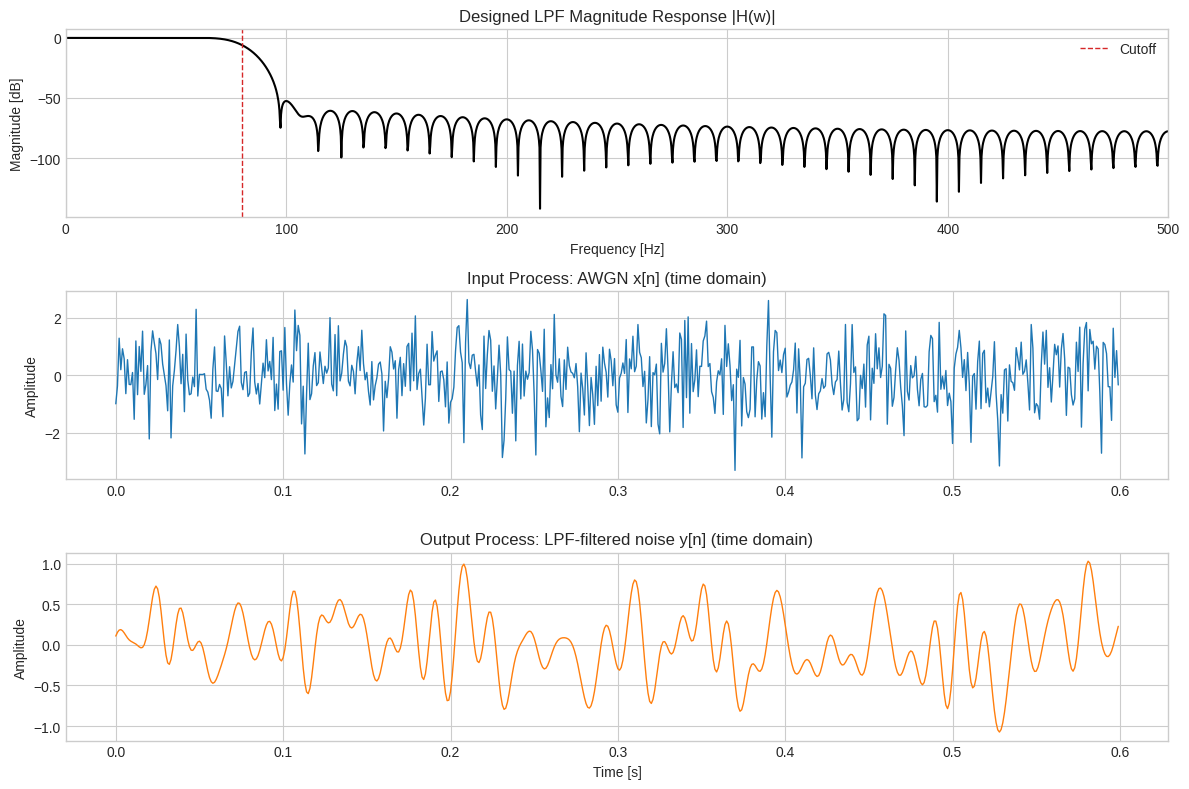

In [2]:
# Simulation parameters with explicit units.
sample_rate_hz: float = 1000.0  # Sampling frequency [Hz]
cutoff_hz: float = 80.0  # LPF cutoff frequency [Hz]
num_taps: int = 101  # FIR length [samples]
num_samples: int = 3000  # Signal length [samples]
noise_std: float = 1.0  # AWGN standard deviation

# Generate AWGN input x[n].
rng_lpf = np.random.default_rng(seed=123)
x_awgn: NDArray[np.float64] = rng_lpf.normal(
    loc=0.0,
    scale=noise_std,
    size=num_samples,
).astype(np.float64)

# Build LPF H(w) and filter x[n] to produce y[n].
h_lpf: NDArray[np.float64] = design_fir_lpf(
    sample_rate_hz=sample_rate_hz,
    cutoff_hz=cutoff_hz,
    num_taps=num_taps,
)
y_lpf: NDArray[np.float64] = np.convolve(x_awgn, h_lpf, mode="same")

# Compare theoretical and empirical output variance.
sigma_y2_theoretical: float = (noise_std**2) * float(np.sum(h_lpf**2))
sigma_y2_empirical: float = float(np.var(y_lpf, ddof=0))
print(f"LPF output variance (theoretical): {sigma_y2_theoretical:.4f}")
print(f"LPF output variance (empirical):   {sigma_y2_empirical:.4f}")

# Compute the discrete frequency response to visualize H(w).
fft_size: int = 4096
h_freq = np.fft.rfft(h_lpf, n=fft_size)
freq_hz: NDArray[np.float64] = np.fft.rfftfreq(
    fft_size,
    d=1.0 / sample_rate_hz,
)

# Plot H(w), AWGN input, and LPF output in the time domain.
segment_samples: int = 600
time_s: NDArray[np.float64] = np.arange(num_samples, dtype=np.float64) / sample_rate_hz

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
axes[0].plot(freq_hz, 20.0 * np.log10(np.maximum(np.abs(h_freq), 1e-8)), color="black")
axes[0].axvline(cutoff_hz, color="tab:red", linestyle="--", linewidth=1.0, label="Cutoff")
axes[0].set_title("Designed LPF Magnitude Response |H(w)|")
axes[0].set_ylabel("Magnitude [dB]")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_xlim(0.0, sample_rate_hz / 2.0)
axes[0].legend()

axes[1].plot(time_s[:segment_samples], x_awgn[:segment_samples], color="tab:blue", linewidth=1.0)
axes[1].set_title("Input Process: AWGN x[n] (time domain)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(time_s[:segment_samples], y_lpf[:segment_samples], color="tab:orange", linewidth=1.0)
axes[2].set_title("Output Process: LPF-filtered noise y[n] (time domain)")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

## 2) AR(3) process (analytical)

The AR(3) model is:

$$x[n] = a_1 x[n-1] + a_2 x[n-2] + a_3 x[n-3] + w[n], \quad w[n] \sim \mathcal{N}(0, \sigma_w^2).$$

With $A(z) = 1 - a_1 z^{-1} - a_2 z^{-2} - a_3 z^{-3}$, the transfer function from
innovation to output is $H(z) = 1/A(z)$. A stable AR part yields a stationary process.

Here we use poles $p = \{0.75, -0.45, 0.25\}$ in the recursion design, which gives:

$$a_1 = 0.55, \quad a_2 = 0.2625, \quad a_3 = -0.084375.$$

AR(3) empirical mean: 0.1153
AR(3) empirical var:  1.8449


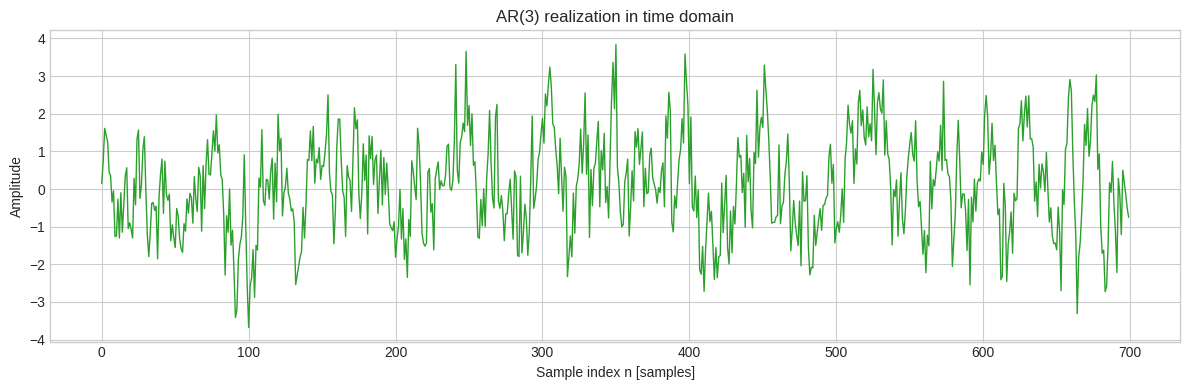

In [3]:
num_samples_ar3: int = 3000  # Output length [samples]
noise_std_ar3: float = 1.0  # Innovation standard deviation
ar3_coeffs: tuple[float, float, float] = (0.55, 0.2625, -0.084375)

x_ar3: NDArray[np.float64] = simulate_ar3(
    num_samples=num_samples_ar3,
    ar_coeffs=ar3_coeffs,
    noise_std=noise_std_ar3,
    burn_in_samples=600,
    random_seed=321,
)

print(f"AR(3) empirical mean: {np.mean(x_ar3):.4f}")
print(f"AR(3) empirical var:  {np.var(x_ar3, ddof=0):.4f}")

segment_samples_ar3: int = 700
n_ar3: NDArray[np.int64] = np.arange(num_samples_ar3, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(n_ar3[:segment_samples_ar3], x_ar3[:segment_samples_ar3], color="tab:green", linewidth=1.0)
ax.set_title("AR(3) realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 3) ARMA(3, 3) process (analytical)

The ARMA(3,3) model is:

$$x[n] = \sum_{k=1}^{3} a_k x[n-k] + w[n] + \sum_{k=1}^{3} b_k w[n-k],$$

with white innovation $w[n]$. The transfer function is:

$$H(z) = \frac{B(z)}{A(z)} = \frac{1 + b_1 z^{-1} + b_2 z^{-2} + b_3 z^{-3}}{1 - a_1 z^{-1} - a_2 z^{-2} - a_3 z^{-3}}.$$

Compared with pure AR, the MA part adds short-memory shaping of innovations,
while the AR part controls recursive structure.

We reuse the same AR coefficients and choose MA coefficients:

$$b_1 = 0.65, \quad b_2 = -0.35, \quad b_3 = 0.15.$$

ARMA(3,3) empirical mean: 0.0902
ARMA(3,3) empirical var:  3.5928


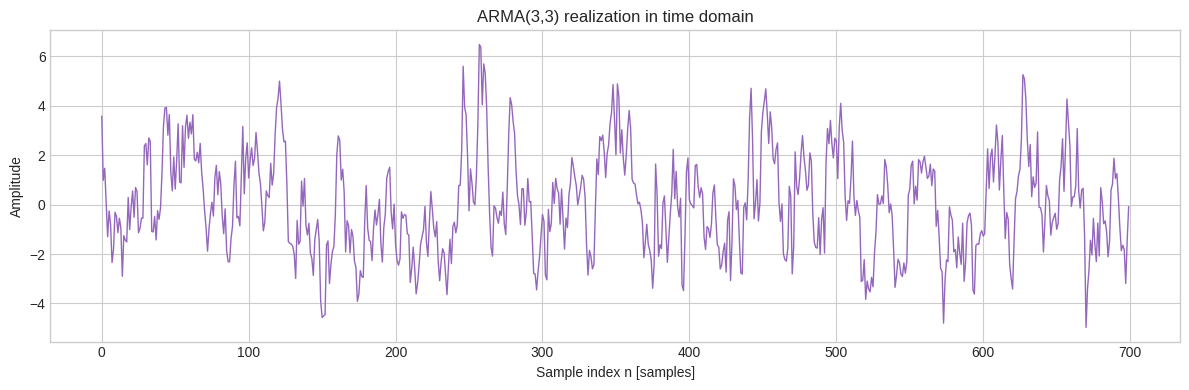

In [4]:
num_samples_arma33: int = 3000  # Output length [samples]
noise_std_arma33: float = 1.0  # Innovation standard deviation
ar_coeffs_arma33: tuple[float, float, float] = (0.55, 0.2625, -0.084375)
ma_coeffs_arma33: tuple[float, float, float] = (0.65, -0.35, 0.15)

x_arma33: NDArray[np.float64] = simulate_arma33(
    num_samples=num_samples_arma33,
    ar_coeffs=ar_coeffs_arma33,
    ma_coeffs=ma_coeffs_arma33,
    noise_std=noise_std_arma33,
    burn_in_samples=600,
    random_seed=999,
)

print(f"ARMA(3,3) empirical mean: {np.mean(x_arma33):.4f}")
print(f"ARMA(3,3) empirical var:  {np.var(x_arma33, ddof=0):.4f}")

segment_samples_arma: int = 700
n_arma: NDArray[np.int64] = np.arange(num_samples_arma33, dtype=np.int64)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    n_arma[:segment_samples_arma],
    x_arma33[:segment_samples_arma],
    color="tab:purple",
    linewidth=1.0,
)
ax.set_title("ARMA(3,3) realization in time domain")
ax.set_xlabel("Sample index n [samples]")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()